<a href="https://colab.research.google.com/github/c-lydia/operating_system/blob/main/os.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Operating System: OS

## Definition

Operating System is a software program that manages a computer's hardware and software resources and provides common services for computer programs. Essentially, it serves as a bridge between users and the computer hardware.

## Functions of OS

- **Process Management**: The OS handles the creation, scheduling, termination, and synchronization of processes (running programs). It allocates resources to processes and ensures they run efficiently without interfering with each other.
- **Memory Management**: The OS manages the computer's primary memory (RAM). It keeps track of which parts of memory are being used by whom, allocates memory space to processes, and deallocates it when no longer needed.
- **File Management**: This involves organizing and keeping track of files and directories (folders) on storage devices. The OS provides services for creating, deleting, accessing, and protecting files.
- **Device Management**: The OS manages all input/output devices (e.g., keyboard, mouse, printer, disk drives) by allocating them to processes, scheduling their usage, and handling their status.
- **Security Management**: The OS protects system resources and user data from unauthorized access or malicious activities. This includes authentication (passwords), authorization (permissions), and implementing firewalls.
- **Network Management**: The OS handles network communication, allowing different computers to connect and share resources. It manages network interfaces, protocols, and data transmission.
- **Storage Management**: Beyond file management, this refers to managing secondary storage devices (hard drives, SSDs). It includes disk scheduling, free space management, and allocating storage space to files.
- **Command Interpreter System**: This is the component that reads and executes commands given by the user, either through a graphical user interface (GUI) or a command-line interface (CLI).

## Command Line Interface

A terminal is a text-based application that allows you to interact with the operating system using commands instead of a graphical user interface (GUI).

A Command Line Interface (CLI) is a text-based way of interacting with a specific program or tool. Instead of clicking buttons in a GUI, you type commands to get the tool to perform actions.

Example:

``` bash
sudo apt update
sudo apt upgrade
```

## How OS works

### The big picture

These terms describe different things: a **bootloader** starts the operating system, the **kernel** manages the machine, **user space and kernel space** describe protected execution environments, and **middleware** provides reusable services for applications.

| Term | Main purpose | Typical location or phase | Examples |
| --- | --- | --- | --- |
| Firmware | Initialize the platform and begin the boot process | Before the OS starts; some services may remain available afterward | UEFI firmware, legacy BIOS |
| Bootloader | Load a kernel and transfer control to it | Early startup | GRUB, U-Boot |
| Kernel | Manage CPU time, memory, devices, and protected resources | Kernel space while the OS runs | Linux kernel, Windows NT kernel |
| Kernel space | Protected environment for kernel code and data | Privileged part of the running system | Scheduler, memory manager, many device drivers |
| User space | Environment where ordinary programs execute | Restricted processes above the kernel interface | Shells, browsers, servers, libraries, system services |
| Middleware | Provide common application services or process requests | Usually user space, inside an application or in separate services | Message brokers, RPC frameworks, HTTP authentication middleware |

The **kernel is part of an operating system**, not the entire operating system. A usable Linux system also includes libraries, an initialization system, utilities, and other user-space software.

### Runtime architecture


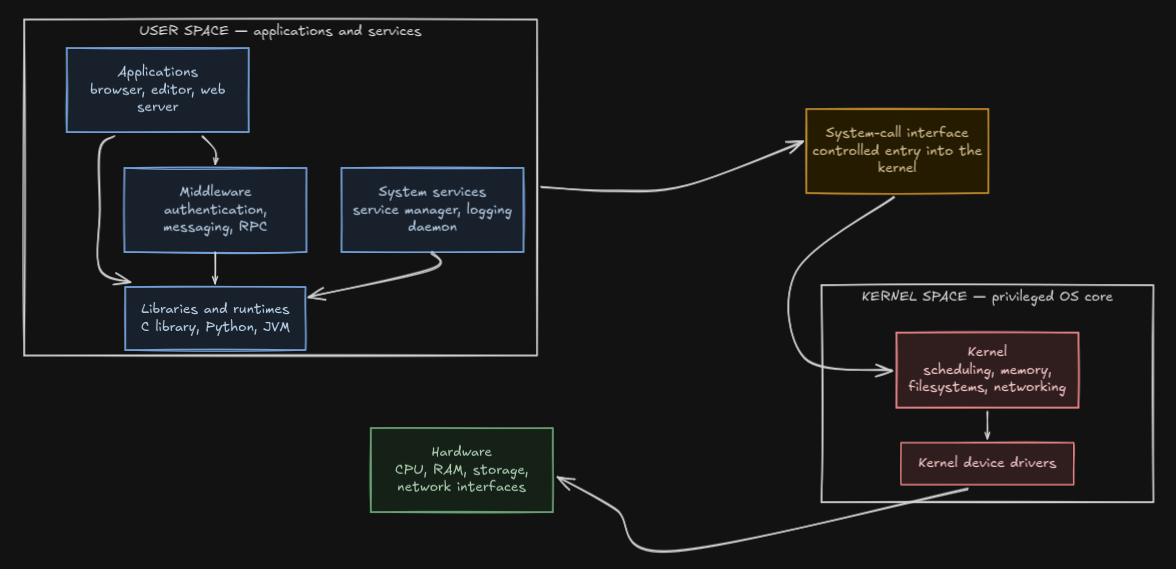

In [8]:
from IPython.display import Image
Image('os_arch.png')

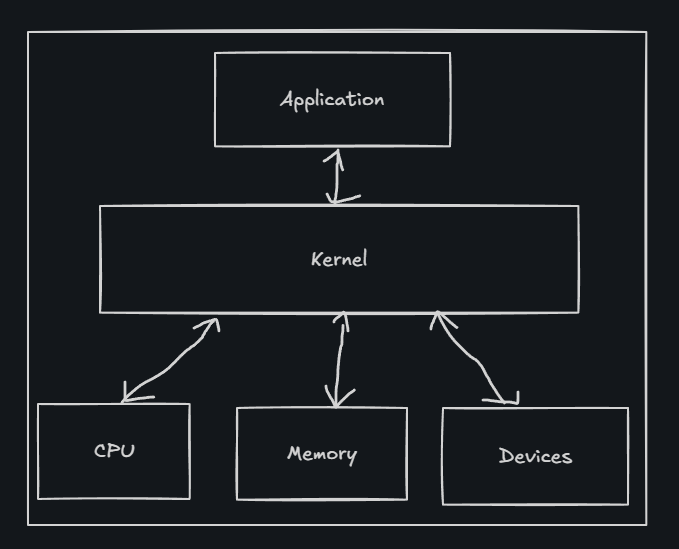

In [ ]:
from IPython.display import Image
Image('kernel.png')

### Kernel: managing shared resources

The kernel is the privileged core of the operating system. It coordinates access to resources so that multiple programs can run without each program directly controlling the entire machine.

| Responsibility | What the kernel does | Everyday example |
| --- | --- | --- |
| CPU scheduling | Chooses which runnable threads execute on each CPU | A browser and music player both make progress |
| Memory management | Maintains virtual-memory mappings and enforces access permissions | One process cannot ordinarily overwrite another process's private memory |
| Process and thread management | Creates, coordinates, and terminates execution contexts | Starting a program or waiting for a child process |
| Filesystems | Provides file abstractions and filesystem operations | Opening a document by its path |
| Device access | Coordinates hardware through drivers | Reading storage or receiving keyboard input |
| Networking | Implements networking mechanisms such as sockets and protocol processing | Sending data over a TCP connection |
| Access control | Checks credentials and permissions for protected operations | Rejecting a file open when the process lacks permission |

A **device driver** understands how to operate a particular device or class of devices. Many Linux drivers execute in kernel space, although some device interactions use user-space drivers or split designs.

Linux uses a **monolithic kernel with loadable modules**: many core services and drivers share the privileged kernel environment. A **microkernel** design keeps a smaller privileged core and places more services in separate user-space processes. The exact boundary depends on the OS design.

### Bootloader: getting the kernel started

A bootloader is a program that prepares and launches an operating-system kernel. Depending on the platform, it can:

- Present a menu of operating systems or kernel versions.
- Load the kernel into memory.
- Load an optional initial RAM filesystem, commonly called an **initramfs** on Linux.
- Provide kernel command-line options and platform information.
- Transfer execution to the kernel's entry point.

The initramfs contains temporary files and early user-space programs that can help locate, unlock, or mount the main root filesystem. It is not the same thing as the kernel.

#### A typical Linux boot sequence


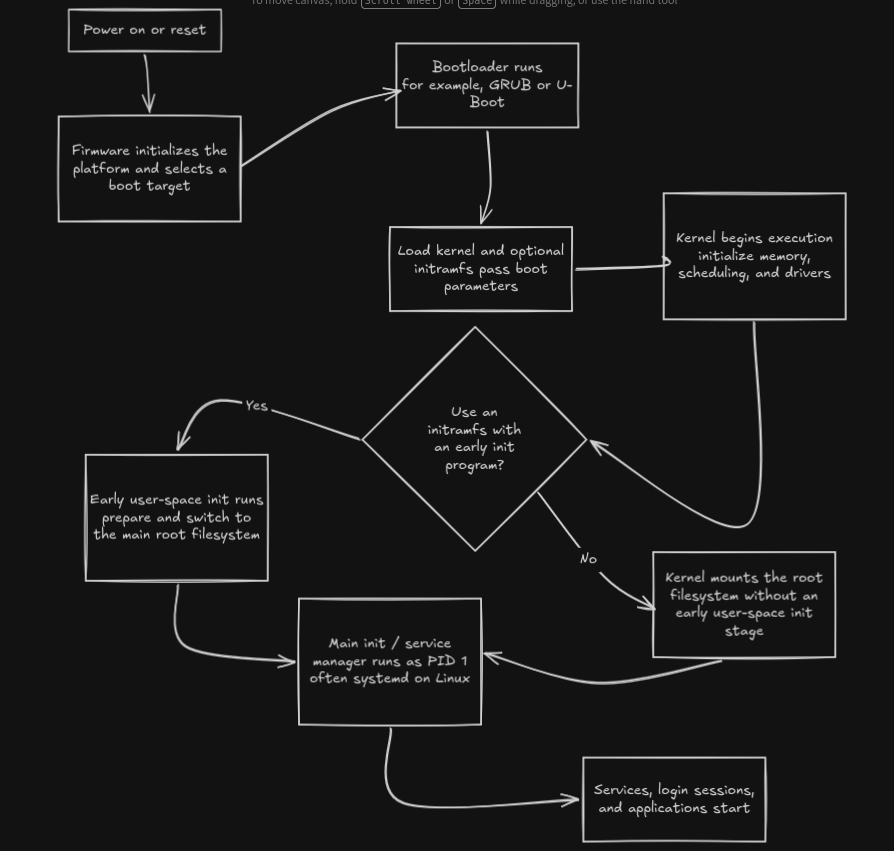

In [7]:
from IPython.display import Image
Image('bootloader.png')


The sequence is **firmware → bootloader → kernel → user-space initialization → services and applications**. With an initramfs, early user space starts before the main root filesystem is ready.

This is a representative sequence, not a universal requirement. Some UEFI systems launch a kernel through its EFI stub without a separate bootloader program. Embedded devices may use several boot stages.

Once control has passed to the kernel, a conventional bootloader does not schedule applications or handle their ongoing file and network requests.

### User space and kernel space

These are protection concepts, not physical places inside the computer.

**User space** contains application code, libraries, runtimes, and most system services. Programs normally execute in **user mode**, where the CPU restricts privileged instructions and memory access.

**Kernel space** contains protected kernel code and data. Kernel code executes in **kernel mode**, with the privileges needed to manage the machine.

Strictly speaking, *space* concerns memory and protection domains, while *mode* concerns the CPU's current execution privilege. The terms are closely related, but they are not interchangeable in every technical discussion.

#### Protection boundaries



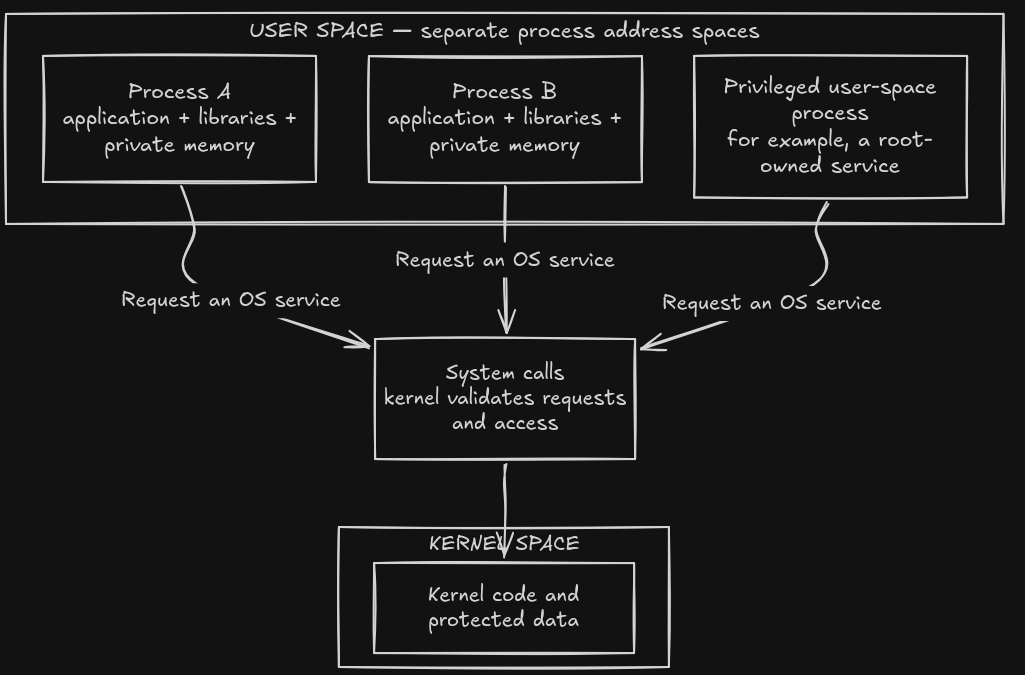

In [6]:
from IPython.display import Image
Image('user_space_kernel_space.png')

Each process normally has its own virtual address space. The same virtual address in two processes need not refer to the same physical memory. Processes can share selected memory through explicit OS mechanisms.

| Question | User space | Kernel space |
| --- | --- | --- |
| What usually runs here? | Applications, daemons, libraries, middleware | Kernel core and many drivers |
| Can code freely access kernel memory? | No; hardware and OS protections restrict access | Kernel code can access protected mappings, subject to architecture and protections |
| How are protected services requested? | Through system calls, often via libraries | Through internal kernel operations and driver interfaces |
| What happens after a serious bug? | Often the affected process crashes; other impact depends on the program | It may compromise or crash the whole system |
| Does administrator status imply kernel mode? | No; administrator programs normally remain user-space processes | Kernel execution is a separate privilege level |

Running `sudo` changes the credentials under which a command executes. It does **not** turn that command into kernel code. The kernel checks those credentials when handling requests; additional security policies and confinement may still apply.

### System calls: crossing the boundary

A **system call** is a defined interface through which a user-space program requests a kernel service. Linux examples include `read`, `write`, `openat`, and `socket`.

A library function and a system call are different things. A library can perform work entirely in user space, issue one system call, or combine several system calls.

For example, `strlen()` can count characters in accessible memory without a system call. A buffered output function may accumulate data in user space and call `write()` only when it flushes its buffer.

#### Example: reading a file

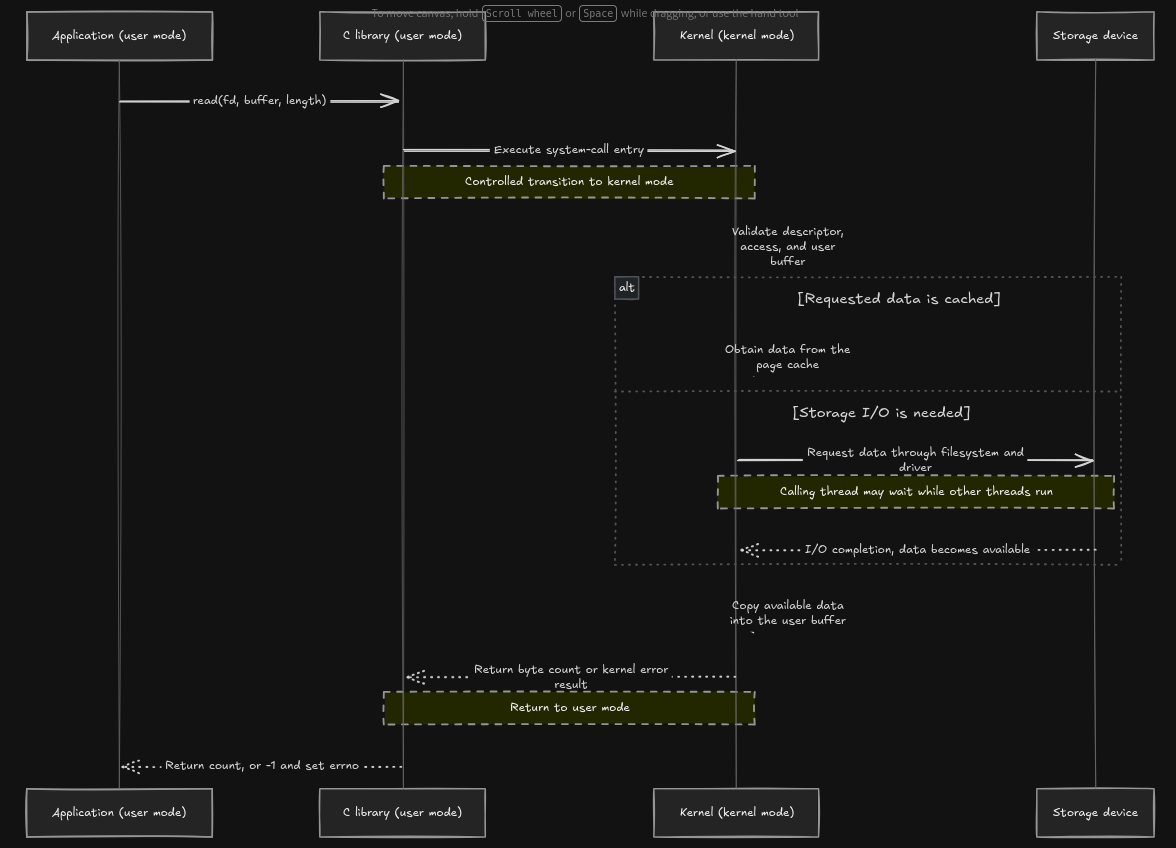

In [9]:
from IPython.display import Image
Image('system_call.png')

This diagram describes a typical buffered read of a regular file. Reads can return fewer bytes than requested, and a return value of zero indicates end of file in this context. Other I/O methods, such as memory-mapped files, follow different paths.

A system call causes a **privilege-mode transition**, but it does not necessarily cause a **thread context switch**. The same calling thread can enter the kernel and return. If it must wait for I/O, the scheduler may run another thread.

The kernel can also gain control through **interrupts** from hardware and **exceptions** such as page faults; system calls are not the only entry mechanism.

### Middleware: reusable services around applications

Middleware is software that supplies shared capabilities or helps application components communicate. It usually runs in user space and relies on the OS for memory, scheduling, files, and networking.

The term is used in two common ways:

| Meaning | What it does | Examples |
| --- | --- | --- |
| Application infrastructure | Supports communication and coordination between applications or services | Message brokers, RPC frameworks, service integration software |
| Request-processing middleware | Wraps an application's request handler with reusable behavior | Authentication, logging, rate limiting, CORS handling |

Middleware may be a library loaded into an application's process, a separate local process, or a service on another machine. It is an architectural role, not a CPU privilege level.

#### Example: an HTTP middleware pipeline


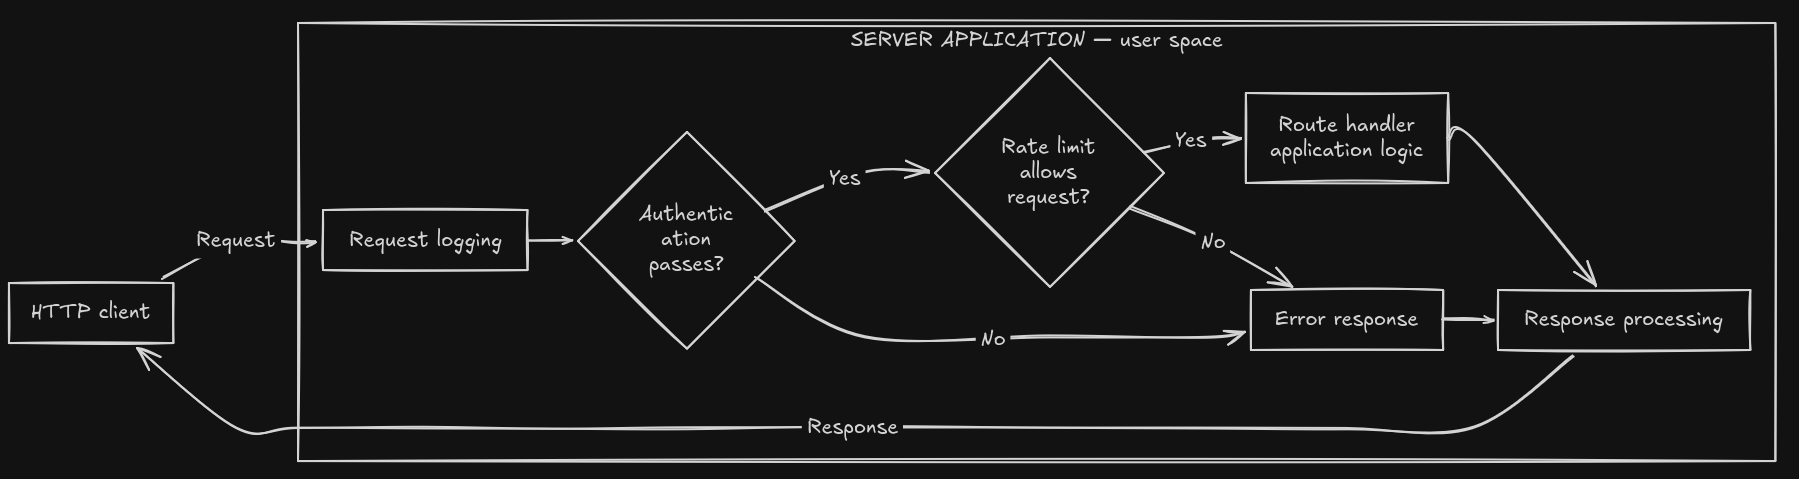

In [13]:
from IPython.display import Image
Image('ex_http_middleware.png')

This is a logical application flow; the underlying sockets and kernel networking are omitted. Middleware order matters. For example, logging placed before authentication can record rejected requests, and a rate limiter placed after authentication can use the authenticated identity.

Different frameworks organize response handling differently. Some unwind through the middleware chain in reverse order. Middleware can also stop a request early without invoking the route handler.

#### Example: messaging between services


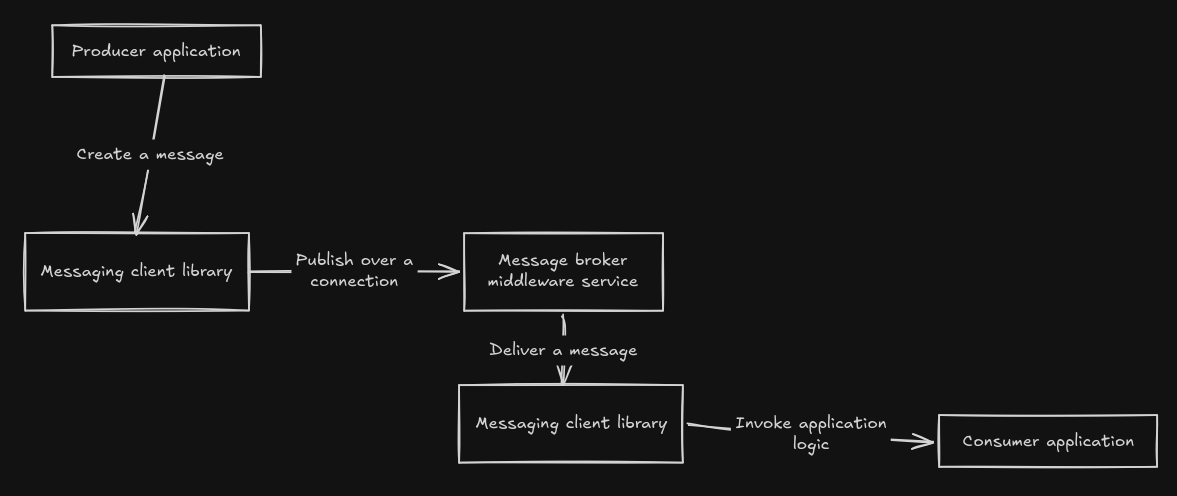

In [15]:
from IPython.display import Image
Image('service_comm.png')

The broker can provide queues, routing, acknowledgments, or persistence, depending on the product and configuration. The producer, broker, and consumer run as user-space programs, potentially on different computers. Their kernels handle the underlying network and storage operations.

### Putting everything together

Imagine starting a Linux computer and opening a web application hosted on it:

1. **Firmware** initializes the platform and selects a boot target.
2. The **bootloader** loads the kernel and any required early boot files, then transfers control.
3. The **kernel** initializes core facilities and starts the first user-space process.
4. Early initialization prepares the system; the main **init/service manager** starts services, including the web server.
5. The web server runs in **user space**. Its runtime and libraries use sockets to receive requests through the kernel.
6. **Middleware** logs the request, checks authentication, or applies other common behavior.
7. The application's handler performs its task. File, network, or other protected operations enter **kernel space** through system calls when needed.
8. The kernel coordinates the necessary work, and the application sends its response.

The kernel remains active throughout the session. Middleware handles application concerns during runtime. The bootloader's normal work took place during startup.

### Common mix-ups

| Misunderstanding | Correction |
| --- | --- |
| “Middleware must sit between every application and the kernel.” | Applications can call OS interfaces without middleware. Middleware provides application services, and its placement varies. |
| “User space means software with a graphical interface.” | Command-line tools, background daemons, databases, and server middleware also run in user space. |
| “A root process runs in kernel space.” | Root is an OS identity with elevated permissions; its programs normally execute in user mode. |
| “The bootloader keeps managing the computer.” | Its main role is to load and start the kernel. The kernel manages the running system. |
| “Every library function enters the kernel.” | Many library functions do all their work in user space. |
| “Every system call switches to another process.” | Entering kernel mode does not by itself require switching threads or processes. |
| “Kernel space is a separate RAM chip.” | It is a protected memory/execution environment, not separate physical hardware. |
| “All operating systems place all drivers in the kernel.” | Driver placement varies; user-space and split driver designs also exist. |

### Quick glossary

- **Process:** A running program instance with resources such as an address space and open file descriptors.
- **Thread:** An execution stream scheduled by the OS; threads in one process share many resources.
- **Daemon:** A background service, usually running in user space.
- **Runtime:** Software that supports program execution, such as the JVM or a Python interpreter.
- **IPC:** Inter-process communication, such as pipes, shared memory, or local sockets.
- **RPC:** Remote procedure call; a framework presents communication with another component in a function-call-like form, with possible latency and communication failures.
- **Virtual memory:** Address translation and protection that give processes their own memory views.
- **Interrupt:** An event, often from hardware, that causes the CPU to transfer control to a handler.
- **Page fault:** An exception triggered when a memory access needs OS handling; it may be a normal demand-paging event or an invalid access.
- **Context switch:** Saving one execution context and restoring another so a different thread or task can run.
- **PID 1:** The first process in a Linux PID namespace; in the initial namespace, it normally performs system initialization or becomes the main init process.

## File System

File system is a way in which files are named and placed in the computer for storage and retrieval.

### Layers of file system

- **Logical file system:** responsible for interaction with user applications
- **VFS (Virtual File System):** is the interface between the kernel and a concrete file system
- **Physical file system:** defines how blocks are being read and written, handles memory management and buffering

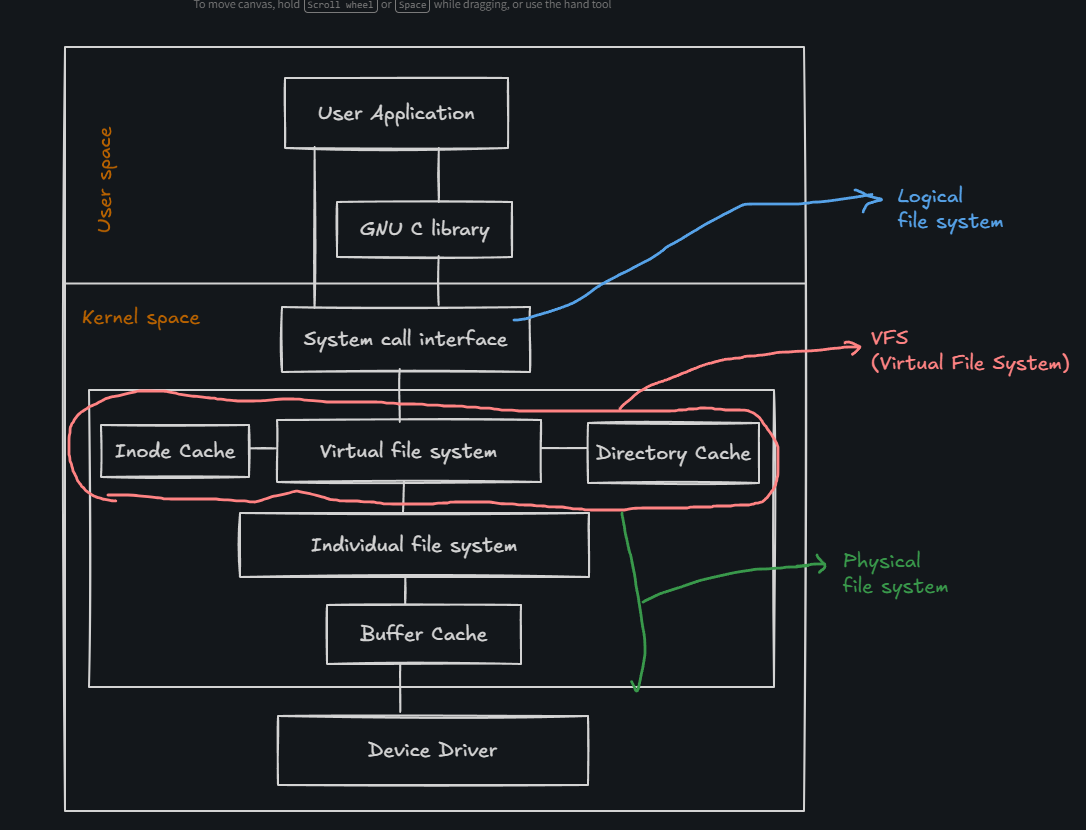

In [ ]:
from IPython.display import Image
Image('file_system.png')

### Directory Structure

- `bin/` (binaries): holds all the programs that live in our machine
- `boot/`: contains all the files required by the kernel at the time of boot and our bootloader also resides in this directory
- `sbin/`: contains system binaries that are required for the system administration
- `dev/`: contains all devices and each device is represented with a file (only the devices attached to the system)
- `etc/` (edit-to-configure): stores all your configuration for software used by the system
- `lib/` (libraries): contains all the libraries that are required to boot the system and used by different applications to perform different functions
- `media/` and `mnt/`: contains the mounted drives
- `opt/`: contains all the manually installed software usually from the vendor
- `proc/`: contains information of the hardware and running processes on the system
- `root/`: considered as `home/` for the root user and only accessed by user with root permission
- `run/`: temporary file system (tmpfs); will be wiped when the system is rebooted or shutdown and contains programs required early in the boot procedure
- `srv/`: stores all files that are accessed by external users when using ftp server
- `sys/` (system): contains files that interact with the kernel
- `tmp/` (temporary): stores files used by applications sessions
- `usr/`: contains shareable, read-only files, including executables and libraries, man files, and other types of documentation
- `var/`: contains files that are expected to grow
- `home/`: storage for user files

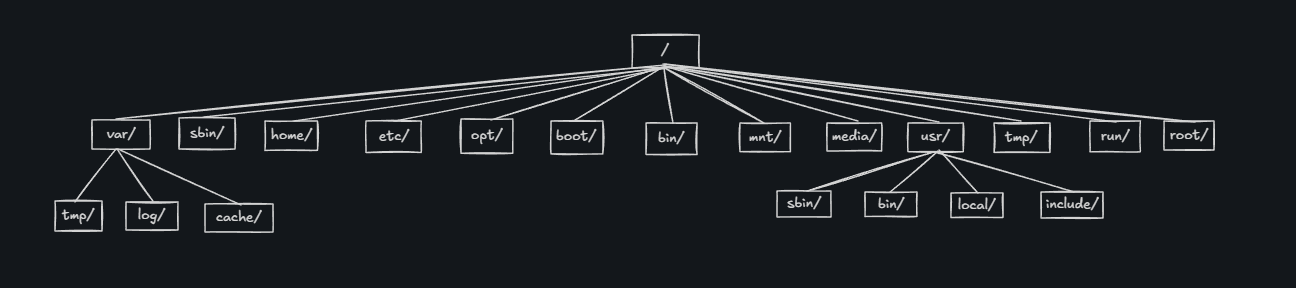

In [ ]:
from IPython.display import Image
Image('dir.png')

### Navigation

- `pwd`: where you are
- `ls`: list directory contents
  - `-l`: detailed view with permissions, owner, and timestamps
  - `-a`: shows hidden files
- `cd`: change directory
  - `~`: moves to `/home`
  - `..`: moves one directory up
  - `-`: switches to last directory
- `find`: search for files
- `locate`: quickly find files

> Note: before using `locate`, run `sudo updatedb` first to refresh it because `locate` works like index searching

### File Operations

- `touch`: creats an empty file
- `cat`: outputs file content
- `cp`: copies files or folders
- `mv`: moves files or renames file
- `rm`: remove file permanently
- `mkdir`: make directory

``` bash
# syntax

touch [filename]
cat [filename]
cp [filename]
cp [filename] [destination] # copy file to another destination
mv [filename] [destination]
mv [filename] [new_filename] # if rename
cp -r [dirname] [destination] # for directories
mv -r [dirname] [destination]
rm [filename]
rm -r [dirname]
rm -rf [dirname] # f = force, r = recursive
mkdir -p [dirname]
```

### Permission




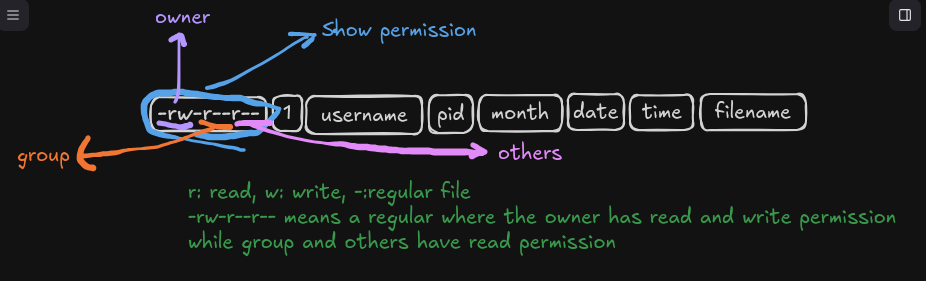

In [6]:
from IPython.display import Image
Image('permission_structure.png')

#### Structure

- File types:
  - `-`: regular file
  - `d`: directory
  - `l`: symbiolic link
- Permission representation goes in this order: `owner, group, others`
- Each set uses:
  - `r`: read
  - `w`: write
  - `x`: execute
- A `-` indicates that permission is not granted

#### Numeric representation

- `4`: read
- `2`: write
- `1`: execute

For each set of permission, these values are summed

- `7 = 4 + 2` -> read, write, and execute
- `6 = 4 + 2` -> read and write
- `5 = 4 + 1` -> read and execute
- `4` -> read

`-rw-r--r-- = 644`

#### permission modification

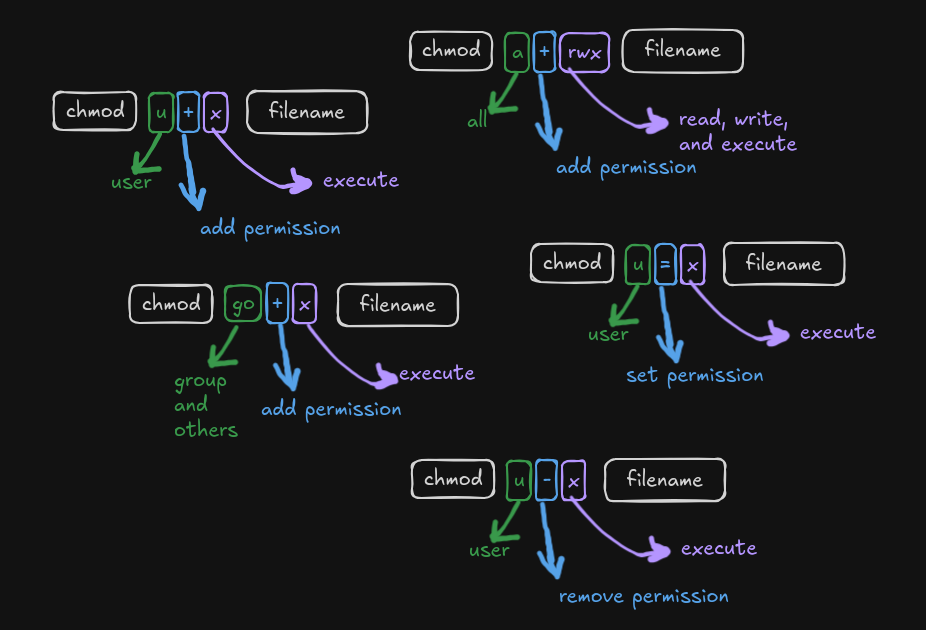

In [7]:
from IPython.display import Image
Image('permission_symbolic.png')

Syntax:

``` bash
chmod [reference][operator][permission] [filename]
```

- `reference`: user, group, others
- `operator`: add, remove, set
- `permission`: read, write, execute

For Numeric mode, use the summed up permission

``` bash
chmod 755 file.txt
```

- `chown`: change ownership

syntax:

``` bash
chown [options][owner]:[group] [filename]
```

Example:

``` bash
chown user2:group1 example.txt
```

## Environment Variables

Environment variables are dynamic values that define the behavior of system processes and applications.

### Types

- **System:** available for all users, set by system admin
- **User:** defined per user
- **Shell:** exists only within running shell session

Some common environment variables:

- `PATH`

``` bash
echo $PATH
export PATH=/usr/local/bin:$PATH
```

- `HOME`

``` bash
echo $HOME
```

- `USER`

stores username of the logged-in users

``` bash
echo $USER
```

- `SHELL`: defines default shell of the user
- `EDITOR`: defines default text editor
- `LANG`: sets system language

### Operations

- View environment variables

``` bash
printenv
env
set | less
```

- Set environment variables

``` bash
export MY_VAR="Hello World"
echo $MY_VAR
```

- Set environment variables permanently

``` bash
echo 'export MY_VAR="Hello World" >> ~/.bashrc
source ~/.bashrc
```

- Unset environment variables

``` bash
unset MY_VAR
echo $MY_VAR
```

## Package Management

Package is a compressed archive containing all files necessary for specific software to run

### Dependencies

The diversity of Linux distribution, each comes with its own tools, libraries, or kernel variation, can lead to compatibility issues

So, packages include a manifest of dependencies

Dependencies are programs and version requirements that must be met for the software to function correctly

### Package Manager

Package Manager is a software that manages the process of installing and uninstalling software

It automates the installation, configuration, and removal of software packages in linux, verify package integrity and authenticity

Package Manager also simplifies tasks such as querying for packages, grouping them by functions, and managing complex dependency chains

#### DPKG (Debian Package Manager)

DPKG installs, removes, upgrades, lists, and verifies packages with `.deb` extension

> DPKG doesn't automatically resolve or manage dependencies

Example: using dpkg with telnet

``` bash
dpkg -i telnet.deb # install
dpkg -r telnet # remove
dpkg -l telnet # list
dpkg -s telnet # check status
```

#### APT (Advance Package Tool)

APT is the user-friendly frontend of DPKG; APT automatically handles dependencies

Example: using APT to update and upgrade system packages

``` bash
sudo apt update
sudo apt upgrade
```

### Troubleshooting package management issues

#### Dependency errors

Dependency errors occur when package A needs package B, but package B is missing

To solve this:

1. Refresh repository metadata

``` bash
sudo apt update
```

2. Run auto repair

``` bash
sudo apt --fix-broken install
```

or

``` bash
sudo dpkg --configure -a
```

3. Escalate to manual fix if it doesn't work

#### Unmet dependencies

``` bash
sudo apt --fix-broken install
```

If that's not enough:

``` bash
sudo dpkg --configure -a
sudo apt-get install -f
```

#### Unable to locate package

``` bash
sudo apt update
sudo apt install [package_name]
```

If the package is in the Universe repository:

``` bash
sudo add-apt-repository universe
sudo apt update
sudo apt install [package_name]
```

#### The following package has been kept back

``` bash
sudo apt install [package_name]
sudo apt full-upgrade
```

#### DPKG broken

``` bash
sudo dpkg --configure -a
```

If specific package is still broken:

``` bash
sudo dpkg --configure [package_name]
```

Force remove and reinstall if it's still broken:

``` bash
sudo dpkg --remove --force-remove-reinstall [package_name]
sudo apt install [package_name]
```

#### GPG key error

``` bash
curl -fsSL https://repo-key-url | sudo gpg --dearmor -o /etc/apt/trusted.gpg.d/repo.gpg
sudo apt update
```

#### Lock file conflict

``` bash
ps aux | grep -E "apt|dpkg"
```

Wait for the process to finish

> Only kill process if it's last resort
> `sudo kill -9 PID`

If no process exists:

``` bash
sudo rm /var/lib/dpkg/lock-frontend
sudo rm /var/lib/dpkg/lock
sudo dpkg --configure -a
```

## Python Package Management

### Pip

Pip = "pip install package" or "preferred installer program"

Basically, pip is the package manager for Python

Pip fetches packages from PyPI (Python Package Index)

PyPI is a public repository with a massive amount of Python projects

### Usage

1. Check pip version

``` bash
pip --version
```

If missing, install pip:

``` bash
python3 -m ensurepip --default-pip
```

2. Install package with pip

``` bash
pip install [package_name]
```

If you want to install multiple packages, you can add those packages into a file `requirements.txt`, then install using pip:

``` bash
pip install -r requirements.txt
```

## Python Virtual Environment (venv)

### The Problem

You want to install a package named `coffee_v1.0` which depends on `beans_v1.0`, `filter_v0.5`, and `grinder_v3.2`

However, your computer installs all packages with the latest versions, i.e., `beans_v3.0`, `filter_v1.6`, and `grinder_v5.0`

But `coffee_v1.0` is installed

So, `coffee_v1.0` can't be run

How do you prevent my computer from installing wrong dependencies?

Virtual Environment enters the group chat

Virtual Environment will isolate the project environment on your computer from the global system environment

### How venv works

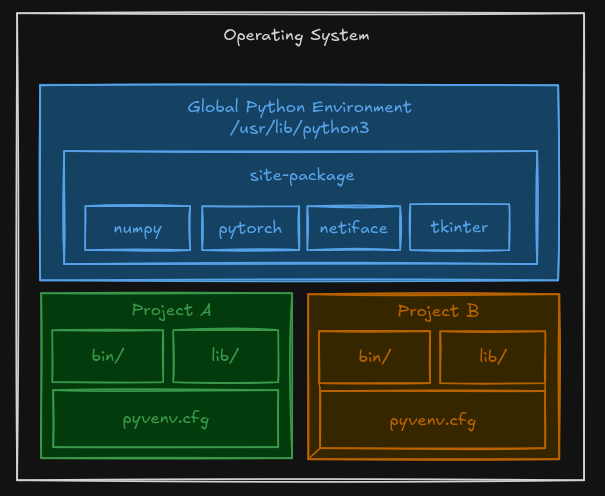

In [16]:
from IPython.display import Image
Image('venv_arch.png')

- Virtual environment borrows the global python interpreter via `pyvenv.cfg`
- Each venv has its own `lib/` and `bin/`, so packages in different venv never conflict
- Everything sits inside OS; the OS filesystem makes this possible

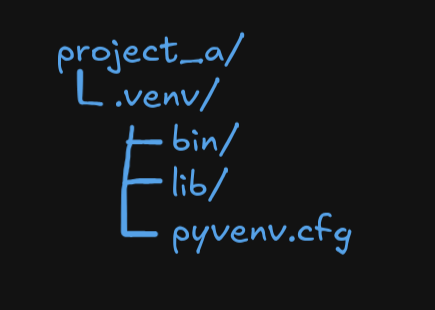

In [17]:
from IPython.display import Image
Image('venv_structure.png')

When you activate a venv, the OS changes the `PATH` environment variable to look in `.venv/bin/` first

When you run `python3`, the OS searches `PATH` and finds the venv's python3 before the global one

But why not just install the correct dependency version into global environment?

If you have more than one projects with the same dependency but different versions, it wouldn't work as there's only one `site-packages` folder

### Usage

1. Install virtual environment

``` bash
pip install virtualenv
```

2. Create project directory

``` bash
mkdir -p project/
```

3. Create vritual environment

``` bash
python -m venv .venv
```

4. Activate

``` bash
source .venv/bin/activate
```

5. Install dependencies

``` bash
python3 -m pip install --upgrade pip
pip install -r requirements.txt
```

6. Deactivate

``` bash
deactivate
```

## Docker

### The Problem

You write some code on your laptop. It works perfectly. You send it to a teammate, it breaks. They have a different OS, a different Python version, different packages installed. Sound familiar?

This is one of the most frustrating problems in software development, and it has a name: **"it works on my machine."**





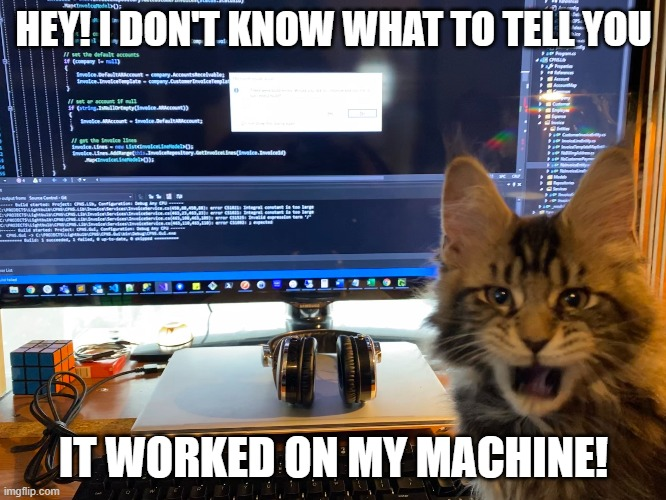

In [20]:
from IPython.display import Image
Image('it_works_on_my_machine.jpg')

Docker solves this.

### What Is Docker?

Docker lets you package your code *together with the environment it runs in* — the OS, the Python version, the packages, everything, into one portable unit. Anyone who runs it gets the exact same environment, no matter what machine they're on.

Think of it like this: instead of shipping just your code and hoping the other person has the right setup, you ship a mini-computer with everything already configured inside.

In this course, we've already built that mini-computer for you. It comes with Ubuntu 22.04, ROS2, Gazebo, and Python, everything you need, ready to go.

### Image vs Container

Before you can use Docker, you need to understand two terms:

**Image:** the blueprint. It's a read-only snapshot of an environment. Think of it like a recipe, or a class in Python. It defines what the environment looks like, but it isn't running yet.

**Container:** a running instance of an image. When you start a container, Docker takes the image and spins up a live, working environment from it. Think of it like an object created from a class.

You can create many containers from the same image, they all start identical, but they run independently.

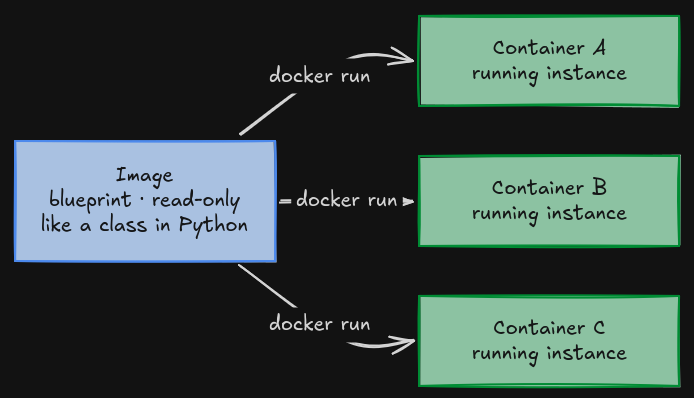

In [21]:
from IPython.display import Image
Image('img_container.png')

### How Does It Actually Work?

A container is not a virtual machine. It doesn't emulate hardware or run a separate OS kernel. It runs directly on your machine's Linux kernel, Docker just makes it *feel* like a separate machine.

It does this using three Linux kernel features:

**Namespaces:** the kernel gives the container its own isolated view of the system. The container sees its own filesystem, its own network, its own process list. From inside, it looks like a completely separate machine. From outside, it's just a process running on your computer.

**cgroups (control groups):** the kernel limits how much CPU, memory, and disk the container is allowed to use. This prevents one container from consuming all your machine's resources.

**Layered filesystem:** the image is not one big file. It's built from layers stacked on top of each other. The base layer might be Ubuntu 22.04. The next layer adds Python. The next adds ROS2. The next adds Gazebo. When you run a container, Docker adds one more writable layer on top, that's where your changes go. The layers below are read-only and shared.

This is why containers start fast and use less disk space than virtual machines, multiple containers can share the same base layers instead of each carrying their own copy.



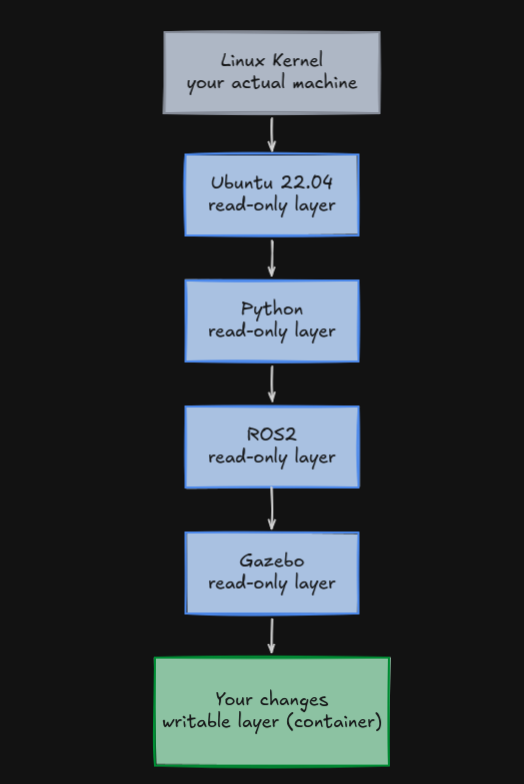

In [22]:
from IPython.display import Image
Image('layered_arch.png')

When the container stops, the writable layer is discarded, which is why files saved outside the mounted workspace disappear.

### How Isolation Actually Works

When you open a terminal inside a Docker container, it feels like a completely separate machine. But your container is not running its own OS, it's sharing your machine's Linux kernel. So how does it feel isolated?

The answer is namespaces. A namespace is a kernel feature that wraps a process and gives it its own private view of a system resource. Docker creates several namespaces for each container:

**PID namespace:** inside the container, processes are numbered starting from 1, as if it's a fresh system. The container has no idea about the thousands of processes running on your actual machine. From your host, you can see the container's processes, but from inside the container, only its own processes are visible.

**Mount namespace:** the container gets its own filesystem tree. When you `ls /`, you see the container's Ubuntu root, not your host machine's files. The two filesystems are completely separate. This is why the container has `/opt/ros/humble` even if ROS2 is not installed on your actual machine.

**Network namespace:** the container gets its own network interfaces and its own IP address. Traffic in and out of the container goes through a virtual network bridge Docker manages. This is why ROS2 nodes inside the container need special network flags to talk to things outside.

**UTS namespace:** the container has its own hostname. That's why your terminal prompt shows a container ID instead of your computer's name.

**User namespace:** the container can have its own root user that maps to a non-root user on the host. This limits what damage a process inside the container can do to your actual machine.



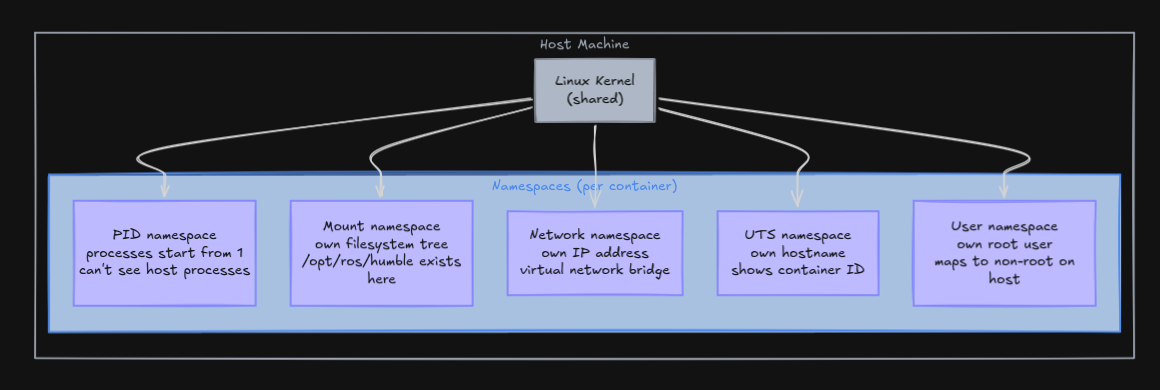

In [23]:
from IPython.display import Image
Image('namespace_structure.png')

So when you type a command inside the container, here's what's actually happening:


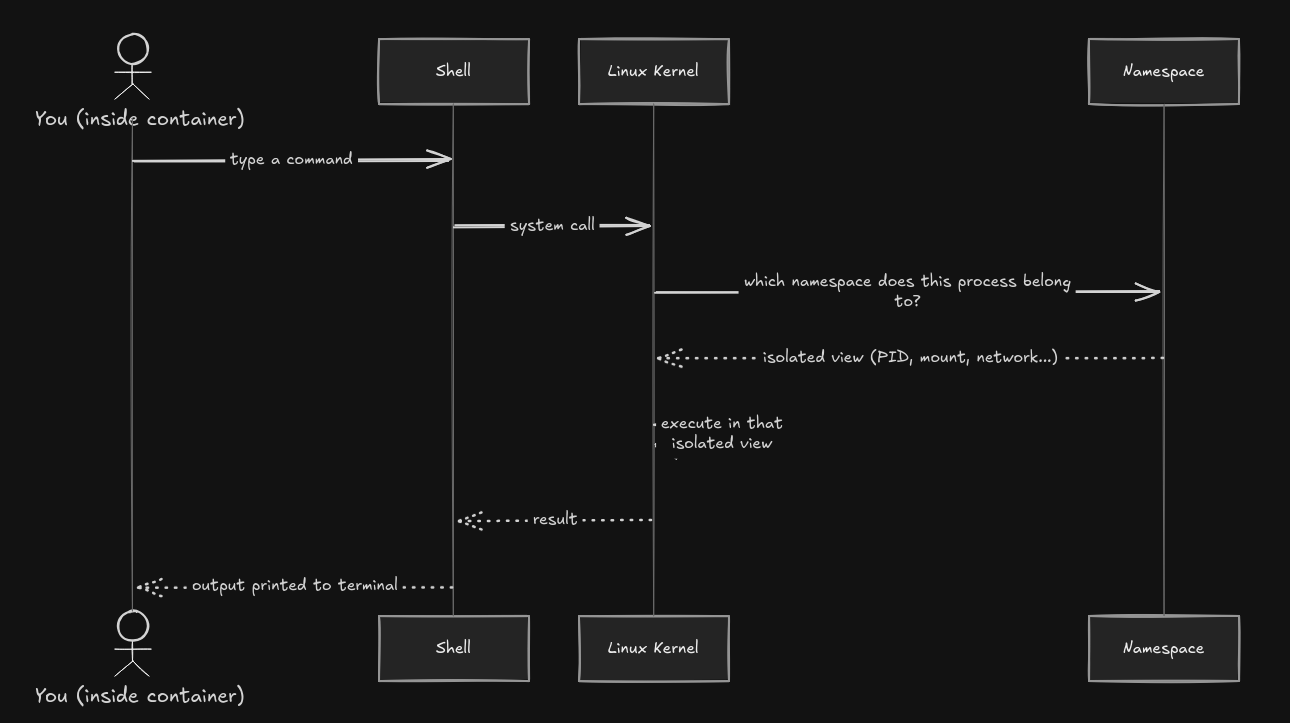

In [24]:
from IPython.display import Image
Image('system_call_docker.png')


The kernel is the same one your host uses. The isolation is just the kernel selectively hiding things based on which namespace the process belongs to.

This is also why Docker only runs natively on Linux. On Windows and Mac, Docker runs a lightweight Linux VM in the background, that VM provides the kernel that containers actually use. When you run Docker on Windows with WSL, WSL is providing that Linux kernel.

### Docker vs Virtual Environment

You've seen venv, which also isolates an environment. So what's the difference?

| | venv | Docker |
|---|---|---|
| What it isolates | Python packages only | The entire OS environment |
| Lives inside | A folder on your machine | A container managed by Docker |
| Uses | Your machine's Python | Its own Ubuntu + Python |
| Startup time | Instant | A few seconds |
| Use case | Isolate Python deps per project | Isolate the entire dev environment |

A venv only solves the Python package conflict problem. It doesn't help if the issue is a different OS, a different system library, or a different version of ROS2.

Docker solves all of that — it packages everything from the OS up. That's why in this course we use Docker to give everyone the same Ubuntu + ROS2 environment, and then use venv inside Docker to manage Python packages for individual projects.



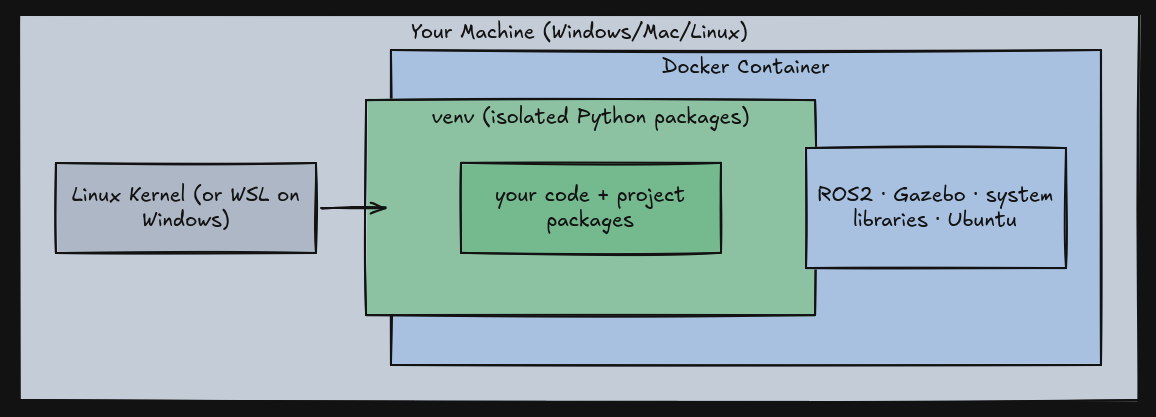

In [25]:
from IPython.display import Image
Image('docker_venv.png')

They're not competing, they work at different levels:

```
Docker container      ← same OS, same ROS2, same system libraries
└── venv              ← same Python packages for your project
    └── your code
```

### How to Use It

#### Starting your container

We've set up a script that handles everything for you. To start your environment, just run:

```bash
bash setup.sh
```

This pulls the image (if you don't have it yet) and starts a container from it. Once it's running, you're inside a Ubuntu terminal, this is where all your work happens.

#### Opening a second terminal

Sometimes you'll need more than one terminal at the same time, for example, running a ROS2 node in one and sending commands in another.

First, find your container name:

```bash
docker ps
```

This lists all running containers. Copy the name from the `NAMES` column, then open a new terminal window on your host machine and run:

```bash
docker exec -it <container_name> bash
```

You're now inside the same container in a second terminal. Both terminals share the same environment and filesystem.

#### Checking if your container is running

```bash
docker ps
```

If your container is running, it shows up here. If the list is empty, your container isn't running — go back and run `bash setup.sh`.

#### Getting out

When you're done, just type:

```bash
exit
```

Or press `Ctrl+D`. This closes your terminal session. The container stops when all terminals are closed.

### One Important Thing

Containers are designed to be disposable. If you create a file inside the container but it's not saved to the mounted workspace folder, **it will be gone when the container stops**.

Always do your work inside the designated workspace folder. That folder is mounted from your actual machine, so your files persist even after the container stops.

### Quick Reference

| What you want to do | Command |
|---|---|
| Start your environment | `bash setup.sh` |
| Open another terminal in the same container | `docker exec -it <name> bash` |
| Check if container is running | `docker ps` |
| Exit the container | `exit` or `Ctrl+D` |

## Resources

- **Operating Systems Concepts**: A classic textbook for understanding OS principles.
  - [Operating System Concepts (Avi Silberschatz, Peter Baer Galvin, Greg Gagne)](https://www.os-book.com/)
- **Linux Command Line Basics**: Tutorials and guides for mastering the command line.
  - [The Linux Command Line (William Shotts)](http://linuxcommand.org/tlcl.php)
  - [Command Line Crash Course](https://ryanstutorials.net/linuxtutorial/commandline.php)
- **File Systems Explained**: Resources to delve deeper into how file systems work.
  - [How a File System Works](https://www.youtube.com/watch?v=b2FjHh2p66g) (Video by Computerphile)
  - [Introduction to File Systems](https://www.geeksforgeeks.org/introduction-of-file-system/)
- **Bootloaders and Kernel**: For deeper understanding of the boot process and kernel functions.
  - [Operating System Boot Process](https://www.geeksforgeeks.org/operating-system-boot-process/) (GeeksforGeeks)
  - [The Linux Kernel Documentation](https://www.kernel.org/doc/)
- **User Space and Kernel Space**: Explanation of these protection concepts.
  - [User Space vs Kernel Space](https://www.geeksforgeeks.org/difference-between-user-space-and-kernel-space/) (GeeksforGeeks)
- **System Calls**: Understanding the interface between user and kernel space.
  - [Linux System Call Quick Reference](https://man7.org/linux/man-pages/man2/syscalls.2.html)
- **Middleware**: Concepts and examples of middleware.
  - [What is Middleware?](https://www.redhat.com/en/topics/middleware/what-is-middleware)
- **Python Package Management (Pip and venv)**: Guides for managing Python environments.
  - [Pip documentation](https://pip.pypa.io/en/stable/)
  - [Python Virtual Environments](https://docs.python.org/3/tutorial/venv.html)
- **Docker**: Resources for containers, images, and isolation.
  - [Docker Documentation](https://docs.docker.com/get-started/)
  - [What is a Container?](https://www.docker.com/resources/what-container/)